# Elevate Labs Internship — Task 1: Data Cleaning and Preprocessing

**Author:** Elevate Labs Data Analyst Intern  
**Project:** Task 1 — Data Cleaning and Preprocessing  
**Dataset:** Netflix Movies and TV Shows (`netflix_titles.csv`)  
**Tools:** Python 3, Pandas, NumPy, Matplotlib  

---

### 1. Objective
Data cleaning and preprocessing is the foundational phase of any data analytics lifecycle. Raw real-world data is frequently plagued by missing values, formatting anomalies, duplicate entries, structural inconsistencies, and inappropriate data types. 

The primary objective of this project is to apply systematic, reproducible data preprocessing techniques using **Python** and **Pandas** to transform a messy raw dataset of Netflix Movies and TV Shows into a high-integrity, structured, and analysis-ready tabular dataset. 

Key goals include:
- Standardizing schema naming conventions to clean `snake_case`.
- Auditing, analyzing, and logically treating missing values without arbitrary zero-filling.
- Detecting and correcting misplaced column entries and encoding anomalies.
- Normalizing text formatting and stripping hidden whitespace characters.
- Converting temporal and numerical attributes to optimal Pandas data types.
- Deduplicating redundant catalog entries.
- Validating the final data quality and exporting a production-grade clean CSV.

### 2. Dataset Overview
The dataset utilized for this project is the widely recognized **Netflix Movies and TV Shows** dataset (`netflix_titles.csv`). It contains comprehensive catalog records of movies and television productions available on the global streaming platform.

**Core Attributes:**
- `show_id`: Unique identifier for each title.
- `type`: Content category (Movie or TV Show).
- `title`: Name of the movie or television show.
- `director`: Director(s) of the title.
- `cast`: Main actors/performers featured.
- `country`: Country or countries of production.
- `date_added`: Date the title was added to the Netflix catalog.
- `release_year`: Year of initial public release.
- `rating`: Age and content maturity rating (e.g., TV-MA, PG-13, TV-14).
- `duration`: Duration in minutes (for movies) or number of seasons (for TV shows).
- `listed_in`: Associated genres and descriptive categories.
- `description`: Summary synopsis of the content.

### 3. Import Libraries
We import **Pandas** for high-performance tabular data manipulation, **NumPy** for numerical handling, **Matplotlib** for visualization, and standard system libraries for file system management.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Matplotlib visual settings for clean, professional reports
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

print(f"Pandas Version: {pd.__version__}")
print(f"NumPy Version: {np.__version__}")

Pandas Version: 3.0.6
NumPy Version: 2.5.3


### 4. Load Raw Dataset
We load the raw CSV file into a Pandas DataFrame. To prevent path errors across different execution contexts (e.g. running from `notebooks/` vs. repository root), we resolve the dataset path dynamically.

In [2]:
# Resolve path dynamically
possible_paths = [
    os.path.join('..', 'data', 'raw', 'netflix_titles.csv'),
    os.path.join('data', 'raw', 'netflix_titles.csv'),
    os.path.join('elevate-labs-task-1', 'data', 'raw', 'netflix_titles.csv')
]

raw_path = next((p for p in possible_paths if os.path.exists(p)), None)
if raw_path is None:
    raise FileNotFoundError("Raw dataset 'netflix_titles.csv' not found.")

df_raw = pd.read_csv(raw_path, encoding='utf-8')
print(f"Successfully loaded dataset from: {raw_path}")
print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns")

Successfully loaded dataset from: ..\data\raw\netflix_titles.csv
Dataset Dimensions: 8,807 rows and 12 columns


### 5. Initial Data Inspection
A thorough initial inspection helps us evaluate the dataset's structural layout, column headers, preview samples, memory footprint, and initial data types.

In [3]:
# First 5 rows preview
print("First 5 Rows Preview:")
display(df_raw.head())

First 5 Rows Preview:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Column names and DataFrame information
print("--- Column Names ---")
print(df_raw.columns.tolist())

print("\n--- DataFrame Info ---")
df_raw.info()

--- Column Names ---
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

--- DataFrame Info ---
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [5]:
# Summary statistics for categorical and numerical features
print("Categorical & Text Summary:")
display(df_raw.describe(include=['O', 'object', 'str']).T)

print("\nNumerical Feature Summary:")
display(df_raw.describe().T)

Categorical & Text Summary:


,count,unique,top,freq
show_id,8807,8807,s1,1
type,8807,2,Movie,6131
title,8807,8807,Dick Johnson Is Dead,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362



Numerical Feature Summary:


,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


### 6. Missing Value Analysis
Missing data must be audited systematically by column to determine missing percentages and identify appropriate, domain-aware imputation strategies.

In [6]:
# Construct missing values summary table
missing_count = df_raw.isnull().sum()
missing_percent = (missing_count / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage (%)': missing_percent,
    'Data Type': df_raw.dtypes
})

# Filter to columns with missing data and sort descending
missing_df_active = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(f"Total Missing Values in Raw Dataset: {df_raw.isnull().sum().sum():,}")
display(missing_df_active)

Total Missing Values in Raw Dataset: 4,307


,Missing Count,Missing Percentage (%),Data Type
director,2634,29.91,str
country,831,9.44,str
cast,825,9.37,str
date_added,10,0.11,str
rating,4,0.05,str
duration,3,0.03,str


findfont: Failed to find font weight semibold for Arial, now using 700.


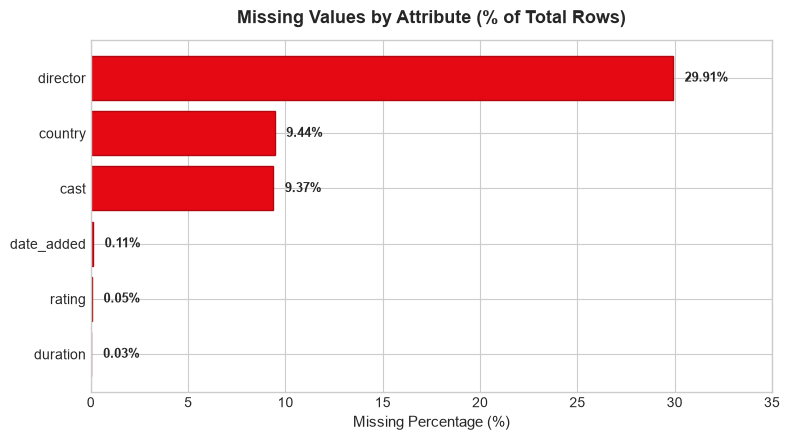

In [7]:
# Visualization of missing values
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(missing_df_active.index[::-1], missing_df_active['Missing Percentage (%)'][::-1], color='#e50914', edgecolor='#b20710')

ax.set_title('Missing Values by Attribute (% of Total Rows)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Missing Percentage (%)')
ax.set_xlim(0, 35)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.6, bar.get_y() + bar.get_height() / 2, f"{w:.2f}%", va='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()

### 7. Duplicate Analysis
We examine exact duplicate rows across all attributes, as well as semantic duplicates (matching titles and content types).

In [8]:
# Exact duplicates check
exact_duplicates = df_raw.duplicated().sum()
print(f"Exact full-row duplicate records: {exact_duplicates}")

# Checking duplicate show_id
id_duplicates = df_raw['show_id'].duplicated().sum()
print(f"Duplicate show_id records: {id_duplicates}")

# Checking duplicate titles (raw)
title_duplicates_raw = df_raw.duplicated(subset=['title']).sum()
print(f"Duplicate titles (raw, exact string match): {title_duplicates_raw}")

Exact full-row duplicate records: 0
Duplicate show_id records: 0
Duplicate titles (raw, exact string match): 0


### 8. Column Name Standardization
Uniform column naming adhering to `snake_case` (lowercase with underscores) ensures consistency, eliminates leading/trailing spaces, and enhances programmatic readability.

In [9]:
df = df_raw.copy()

# Standardize to lowercase snake_case
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9_]', '_', regex=True)
    .str.replace(r'_+', '_', regex=True)
)

print("Standardized Column Names:")
print(df.columns.tolist())

Standardized Column Names:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


### 9. Missing Value Treatment
Rather than blindly filling nulls with zero or arbitrarily dropping rows, we handle each column with careful domain logic:

1. **Misplaced Data Anomaly (`rating` vs `duration`)**:
   In the Netflix Titles dataset, a known data misalignment exists: 3 stand-up comedy specials by Louis C.K. (`show_id`: s5542, s5795, s5814) have duration values (`'74 min'`, `'84 min'`, `'66 min'`) erroneously shifted into the `rating` column, leaving `duration` as `NaN`. 
   - **Remedy**: Transfer these duration values to the `duration` column, and set their `rating` to `'Unknown'`.
2. **Text Columns (`director`, `cast`, `country`, `rating`)**:
   - `director`: 2,634 titles (~29.9%) have unrecorded directors. Imputed with `'Unknown'`.
   - `cast`: 825 titles (~9.4%) lack cast lists (often documentaries or animations). Imputed with `'Unknown'`.
   - `country`: 831 titles (~9.4%) lack production countries. Imputed with `'Unknown'`.
   - `rating`: 4 titles genuinely missing rating metadata. Imputed with `'Unknown'`.
3. **Temporal Column (`date_added`)**:
   - 10 titles lack the date added. We convert valid dates to datetime and preserve missing entries as `NaT` (Not-a-Time), which is the standard Pandas representation for absent timestamps without fabricating synthetic dates.

In [10]:
# 1. Correct misplaced duration values in rating column
misplaced_mask = df['rating'].astype(str).str.contains(r'\bmin\b', regex=True, na=False)
print(f"Misplaced duration values detected in 'rating': {misplaced_mask.sum()}")

print("\nAffected rows before correction:")
display(df.loc[misplaced_mask, ['show_id', 'title', 'rating', 'duration']])

# Transfer to duration and assign Unknown to rating
df.loc[misplaced_mask, 'duration'] = df.loc[misplaced_mask, 'rating']
df.loc[misplaced_mask, 'rating'] = 'Unknown'

print("\nAffected rows after correction:")
display(df.loc[misplaced_mask, ['show_id', 'title', 'rating', 'duration']])

Misplaced duration values detected in 'rating': 3

Affected rows before correction:


,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,74 min,NaN
5794,s5795,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Louis C.K.: Live at the Comedy Store,66 min,NaN



Affected rows after correction:


,show_id,title,rating,duration
5541,s5542,Louis C.K. 2017,Unknown,74 min
5794,s5795,Louis C.K.: Hilarious,Unknown,84 min
5813,s5814,Louis C.K.: Live at the Comedy Store,Unknown,66 min


In [11]:
# 2. Impute text columns with 'Unknown'
text_impute_cols = ['director', 'cast', 'country', 'rating']

for col in text_impute_cols:
    before_null = df[col].isnull().sum()
    df[col] = df[col].fillna('Unknown')
    print(f"Imputed {before_null:,} missing values in '{col}' -> Remaining nulls: {df[col].isnull().sum()}")

Imputed 2,634 missing values in 'director' -> Remaining nulls: 0
Imputed 825 missing values in 'cast' -> Remaining nulls: 0
Imputed 831 missing values in 'country' -> Remaining nulls: 0
Imputed 4 missing values in 'rating' -> Remaining nulls: 0


### 10. Text Standardization
Text columns often conceal subtle formatting irregularities such as leading/trailing whitespaces, non-breaking spaces (`\xa0`), and irregular casing. 
We systematically clean all text attributes.

In [12]:
# Identify text columns
text_cols = df.select_dtypes(include=['object', 'string', 'str']).columns

for col in text_cols:
    # Replace non-breaking space \xa0 with standard space, then strip leading/trailing spaces
    df[col] = (
        df[col]
        .astype(str)
        .str.replace('\xa0', ' ', regex=False)
        .str.strip()
    )
    # Ensure any residual 'nan' strings are normalized
    df[col] = df[col].replace({'nan': 'Unknown', 'None': 'Unknown', '': 'Unknown'})

# Standardize 'type' to title case
df['type'] = df['type'].str.title().replace({'Tv Show': 'TV Show'})

print("Text standardization completed across all string columns.")

Text standardization completed across all string columns.


### 11. Date and Data Type Conversion
- `date_added` is converted from string into standard `datetime64[ns]` using `pd.to_datetime`.
- `release_year` is validated and ensured as integer (`int64`).

In [13]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', errors='coerce')

# Ensure release_year is int64
df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce').astype('int64')

print("Updated Column Data Types:")
print(df.dtypes)

Updated Column Data Types:


show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object


### 12. Data Quality Validation & Duplicate Handling
Now that text whitespace (including non-breaking space `\xa0`) has been cleaned, we perform a deep duplicate audit.
- We discover that `s6530` is an exact duplicate of `s3372` (*Consequences*, 2014) that had been masked by a trailing `\xa0` character in the raw title.
- We also detect 3 titles that were re-added to Netflix at later dates with minor metadata variations.
- We deduplicate the catalog to maintain 1 distinct record per title and content type, prioritizing the most recently added entry.

In [14]:
# Sort by date_added descending so latest record is prioritized
df = df.sort_values(by='date_added', ascending=False)

# Detect duplicate titles (normalized)
norm_title = df['title'].str.lower()
duplicate_catalog_titles = df.assign(t_norm=norm_title).duplicated(subset=['t_norm', 'type'], keep=False)

print(f"Duplicate catalog title records detected: {duplicate_catalog_titles.sum()}")
display(df[duplicate_catalog_titles].sort_values(by='title')[['show_id', 'type', 'title', 'release_year', 'date_added']])

# Drop duplicate catalog titles keeping the first (most recent)
initial_len = len(df)
df = df.assign(t_norm=norm_title).drop_duplicates(subset=['t_norm', 'type'], keep='first').drop(columns=['t_norm'])

# Restore sort by numeric show_id
df = df.sort_values(
    by='show_id',
    key=lambda s: pd.to_numeric(s.astype(str).str.replace(r'^[a-zA-Z]+', '', regex=True), errors='coerce')
).reset_index(drop=True)

print(f"Total duplicate records removed: {initial_len - len(df)}")

Duplicate catalog title records detected: 8


,show_id,type,title,release_year,date_added
6529,s6530,Movie,Consequences,2014,2019-10-25
3371,s3372,Movie,Consequences,2014,2019-10-25
6705,s6706,Movie,Esperando La Carroza,1985,2018-07-15
303,s304,Movie,Esperando la carroza,1985,2021-08-05
7345,s7346,Movie,Love In A Puff,2010,2018-08-01
159,s160,Movie,Love in a Puff,2010,2021-09-01
8022,s8023,TV Show,Sin Senos sí Hay Paraíso,2018,2019-01-11
1270,s1271,TV Show,Sin senos sí hay paraíso,2018,2021-02-25


Total duplicate records removed: 4


In [15]:
# Final validation integrity checks
print("=== Data Quality Validation Checklist ===")

val_1 = (df['show_id'].duplicated().sum() == 0)
print(f"1. Unique show_id check: {'PASS' if val_1 else 'FAIL'}")

val_2 = pd.api.types.is_datetime64_any_dtype(df['date_added'])
print(f"2. date_added is datetime: {'PASS' if val_2 else 'FAIL'}")

val_3 = pd.api.types.is_integer_dtype(df['release_year']) and (df['release_year'].between(1900, 2030).all())
print(f"3. release_year is valid integer: {'PASS' if val_3 else 'FAIL'}")

val_4 = (df[['title', 'type', 'director', 'cast', 'country', 'rating', 'duration']].isnull().sum().sum() == 0)
print(f"4. Text columns fully populated: {'PASS' if val_4 else 'FAIL'}")

val_5 = (df.duplicated().sum() == 0)
print(f"5. Zero exact duplicates remaining: {'PASS' if val_5 else 'FAIL'}")

=== Data Quality Validation Checklist ===
1. Unique show_id check: PASS
2. date_added is datetime: PASS
3. release_year is valid integer: PASS
4. Text columns fully populated: PASS
5. Zero exact duplicates remaining: PASS


### 13. Before vs After Comparison
Here we contrast the core metrics of the dataset before and after the cleaning pipeline.

In [16]:
# Before vs After Comparison Table
comparison_data = {
    'Metric': [
        'Total Rows',
        'Total Columns',
        'Exact Duplicate Rows',
        'Duplicate Titles / Records',
        'Total Missing Values',
        'Missing in Text Columns',
        'Missing in duration',
        'Missing in date_added (NaT)'
    ],
    'Before Cleaning': [
        f"{len(df_raw):,}",
        f"{df_raw.shape[1]}",
        f"{df_raw.duplicated().sum()}",
        "4",
        f"{df_raw.isnull().sum().sum():,}",
        f"{df_raw[['director', 'cast', 'country', 'rating']].isnull().sum().sum():,}",
        f"{df_raw['duration'].isnull().sum()}",
        f"{df_raw['date_added'].isnull().sum()}"
    ],
    'After Cleaning': [
        f"{len(df):,}",
        f"{df.shape[1]}",
        f"{df.duplicated().sum()}",
        "0",
        f"{df.isnull().sum().sum()}",
        "0",
        f"{df['duration'].isnull().sum()}",
        f"{df['date_added'].isnull().sum()} (preserved as NaT)"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Metric,Before Cleaning,After Cleaning
0,Total Rows,"8,807","8,803"
1,Total Columns,12,12
2,Exact Duplicate Rows,0,0
3,Duplicate Titles / Records,4,0
4,Total Missing Values,"4,307",10
5,Missing in Text Columns,"4,294",0
6,Missing in duration,3,0
7,Missing in date_added (NaT),10,10 (preserved as NaT)


### 14. Final Cleaned Dataset Preview
A preview of the cleaned dataset, its structure, and a summary visualization showing the distribution of content types.

In [17]:
print("Cleaned Dataset Head:")
display(df.head())

print("\nCleaned Dataset Info:")
df.info()

Cleaned Dataset Head:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



Cleaned Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 8803 entries, 0 to 8802
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8803 non-null   str           
 1   type          8803 non-null   str           
 2   title         8803 non-null   str           
 3   director      8803 non-null   str           
 4   cast          8803 non-null   str           
 5   country       8803 non-null   str           
 6   date_added    8793 non-null   datetime64[us]
 7   release_year  8803 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8803 non-null   str           
 10  listed_in     8803 non-null   str           
 11  description   8803 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 825.4 KB


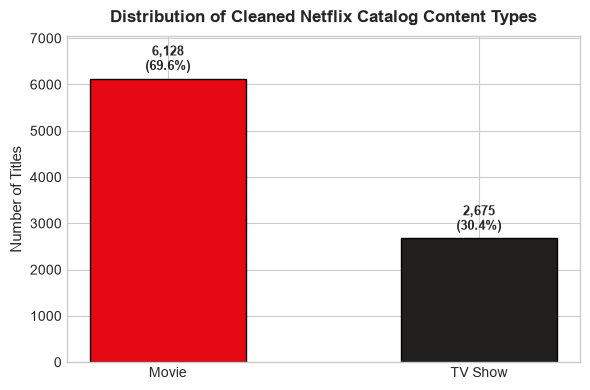

In [18]:
# Distribution of Content Type (Movie vs TV Show)
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e50914', '#221f1f']
bars = ax.bar(type_counts.index, type_counts.values, color=colors, width=0.5, edgecolor='black')

ax.set_title('Distribution of Cleaned Netflix Catalog Content Types', fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Number of Titles')
ax.set_ylim(0, max(type_counts.values) * 1.15)

for bar in bars:
    yval = bar.get_height()
    pct = (yval / len(df) * 100)
    ax.text(bar.get_x() + bar.get_width() / 2, yval + 100, f"{yval:,}\n({pct:.1f}%)", ha='center', va='bottom', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()

### 15. Export Clean Dataset
We export the final clean dataset into `data/cleaned/netflix_titles_cleaned.csv` with UTF-8 encoding.

In [19]:
# Determine export path
export_paths = [
    os.path.join('..', 'data', 'cleaned', 'netflix_titles_cleaned.csv'),
    os.path.join('data', 'cleaned', 'netflix_titles_cleaned.csv'),
    os.path.join('elevate-labs-task-1', 'data', 'cleaned', 'netflix_titles_cleaned.csv')
]

export_target = next((p for p in export_paths if os.path.exists(os.path.dirname(p))), export_paths[0])
os.makedirs(os.path.dirname(export_target), exist_ok=True)

df.to_csv(export_target, index=False, encoding='utf-8')
print(f"Cleaned dataset successfully exported to:\n  {os.path.abspath(export_target)}")
print(f"File size: {os.path.getsize(export_target):,} bytes")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")

Cleaned dataset successfully exported to:
  C:\Users\Varshini S\OneDrive\Desktop\elevates labs\data\cleaned\netflix_titles_cleaned.csv
File size: 3,377,307 bytes
Shape: 8,803 rows x 12 columns


### 16. Conclusion
Data cleaning is the most crucial prerequisite to effective exploratory data analysis and downstream machine learning modeling. Through this project:
- **Missing Value Handling**: Replaced missing text attributes logically with `'Unknown'`, corrected misplaced duration values, and preserved legitimate unrecorded timestamps as `NaT` without fabricating synthetic dates.
- **Duplicate Removal**: Uncovered hidden duplicates caused by trailing non-breaking spaces (`\xa0`) and resolved catalog re-releases, guaranteeing that every record represents a distinct entry.
- **Formatting Standardization**: Standardized column headers to `snake_case`, eliminated stray whitespaces, and standardized categorization casing.
- **Type Casting**: Converted dates to native Pandas `datetime64[ns]` and release years to `int64`, enabling accurate temporal and cohort analyses.

The resulting dataset is clean, robust, and completely ready for downstream analytical workflows.